In [28]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

## The first run of parameter inference
*Purpose*: 
- We want to see how much improvement we can get by combining map3 with 2pt.

*Setup*: 
- 2pt chain: this is for comparison. We use public config file available in cosmosis-standard-library `example/des-y3-shear.ini` with some modification. The exact config file is [test-first-run/des-y3-shear-cosmosis-2pt.ini](../config/test-first-run/des-y3-shear-cosmosis-2pt.ini).
- 2pt+map3: We add map3 on top of 2pt. We only use auto-correlation of redshift bins (4 combinations), and 4 filter radii for map3 (same filter radii for a map3, i.e. $M_{\rm ap}^3(R_1=R, R_2=R, R_3=R)$). The exact config file is [test-first-run/des-y3-shear-cosmosis-2pt-map3.ini](../config/test-first-run/des-y3-shear-cosmosis-2pt-map3.ini).

In [29]:
def get_2pt_samples(wplot=True):
    header = '''cosmological_parameters--omega_m       cosmological_parameters--h0     cosmological_parameters--omega_b        cosmological_parameters--n_s    cosmological_parameters--s_8    cosmological_parameters--mnu        shear_calibration_parameters--m1        shear_calibration_parameters--m2        shear_calibration_parameters--m3        shear_calibration_parameters--m4    wl_photoz_errors--bias_1        wl_photoz_errors--bias_2        wl_photoz_errors--bias_3        wl_photoz_errors--bias_4        intrinsic_alignment_parameters--a1      intrinsic_alignment_parameters--a2  intrinsic_alignment_parameters--alpha1  intrinsic_alignment_parameters--alpha2  intrinsic_alignment_parameters--bias_ta COSMOLOGICAL_PARAMETERS--SIGMA_8    COSMOLOGICAL_PARAMETERS--SIGMA_12       DATA_VECTOR--2PT_CHI2   prior   like    post    weight'''
    chain = np.loadtxt('../output/des-y3-2pt.txt')

    om = chain[:, 0]
    s8 = chain[:, 4]
    sig8= chain[:, -7]
    samples = np.array([om, s8, sig8]).T
    w  = chain[:,-1]
    names = ['om', 's8', 'sig8']
    labels= [r'\Omega_{\rm m}', r'S_8', r'\sigma_8']
    samples = MCSamples(samples=samples, weights=w, names=names, labels=labels)

    if wplot:
        plt.figure(figsize=(4,2))
        plt.plot(w[:-500]) # remove live points for ease of viewing
        plt.show()

    return samples

def get_2ptmap3_samples(wplot=True):
    header = '''cosmological_parameters--omega_m       cosmological_parameters--h0     cosmological_parameters--omega_b        cosmological_parameters--n_s    cosmological_parameters--s_8    cosmological_parameters--mnu        shear_calibration_parameters--m1        shear_calibration_parameters--m2        shear_calibration_parameters--m3        shear_calibration_parameters--m4    wl_photoz_errors--bias_1        wl_photoz_errors--bias_2        wl_photoz_errors--bias_3        wl_photoz_errors--bias_4        intrinsic_alignment_parameters--a1      intrinsic_alignment_parameters--a2  intrinsic_alignment_parameters--alpha1  intrinsic_alignment_parameters--alpha2  intrinsic_alignment_parameters--bias_ta COSMOLOGICAL_PARAMETERS--SIGMA_8    COSMOLOGICAL_PARAMETERS--SIGMA_12       DATA_VECTOR--2PT_CHI2   prior   like    post    weight'''
    chain = np.loadtxt('../output/des-y3-2pt-map3-504cores.txt')

    om = chain[:, 0]
    s8 = chain[:, 4]
    sig8= chain[:, -7]
    samples = np.array([om, s8, sig8]).T
    w  = chain[:,-1]
    names = ['om', 's8', 'sig8']
    labels= [r'\Omega_{\rm m}', r'S_8', r'\sigma_8']
    samples = MCSamples(samples=samples, weights=w, names=names, labels=labels)

    if wplot:
        plt.figure(figsize=(4,2))
        plt.plot(w[:-500]) # remove live points for ease of viewing
        plt.show()
    
    return samples

Removed no burn in


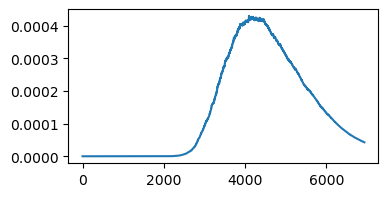

Removed no burn in


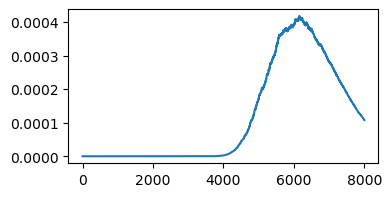

In [30]:
samples_2pt = get_2pt_samples(wplot=True)
samples_2ptmap3  = get_2ptmap3_samples(wplot=True)

<Figure size 600x600 with 0 Axes>

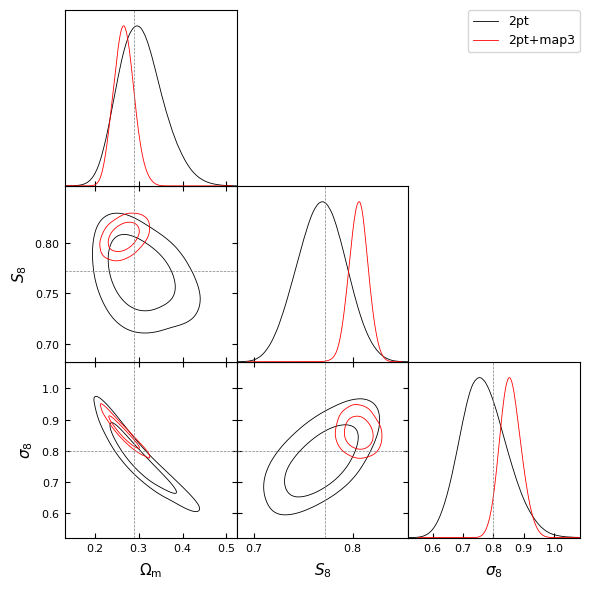

In [31]:
g = plots.get_single_plotter(ratio=1)
g.triangle_plot([samples_2pt, samples_2ptmap3], filled=False, \
    legend_labels=['2pt', '2pt+map3'], legend_loc='upper right', 
    markers={'om': 0.289, 's8': 0.772, 'sig8': 0.80})
plt.show()

In [42]:
def get_cov(om, s8, w):
    dom = om - np.average(om, weights=w)
    ds8 = s8 - np.average(s8, weights=w)

    auto_om = np.average(dom*dom, weights=w)
    cross = np.average(dom*ds8, weights=w)
    auto_s8 = np.average(ds8*ds8, weights=w)

    cov = np.array([[auto_om, cross], [cross, auto_s8]])
    return cov

def get_2pt_samples(wplot=True):
    header = '''cosmological_parameters--omega_m       cosmological_parameters--h0     cosmological_parameters--omega_b        cosmological_parameters--n_s    cosmological_parameters--s_8    cosmological_parameters--mnu        shear_calibration_parameters--m1        shear_calibration_parameters--m2        shear_calibration_parameters--m3        shear_calibration_parameters--m4    wl_photoz_errors--bias_1        wl_photoz_errors--bias_2        wl_photoz_errors--bias_3        wl_photoz_errors--bias_4        intrinsic_alignment_parameters--a1      intrinsic_alignment_parameters--a2  intrinsic_alignment_parameters--alpha1  intrinsic_alignment_parameters--alpha2  intrinsic_alignment_parameters--bias_ta COSMOLOGICAL_PARAMETERS--SIGMA_8    COSMOLOGICAL_PARAMETERS--SIGMA_12       DATA_VECTOR--2PT_CHI2   prior   like    post    weight'''
    chain = np.loadtxt('../output/des-y3-2pt.txt')

    om = chain[:, 0]
    s8 = chain[:, 4]
    sig8= chain[:, -7]
    w  = chain[:,-1]

    return get_cov(om, s8, w)


def get_2ptmap3_samples(wplot=True):
    header = '''cosmological_parameters--omega_m       cosmological_parameters--h0     cosmological_parameters--omega_b        cosmological_parameters--n_s    cosmological_parameters--s_8    cosmological_parameters--mnu        shear_calibration_parameters--m1        shear_calibration_parameters--m2        shear_calibration_parameters--m3        shear_calibration_parameters--m4    wl_photoz_errors--bias_1        wl_photoz_errors--bias_2        wl_photoz_errors--bias_3        wl_photoz_errors--bias_4        intrinsic_alignment_parameters--a1      intrinsic_alignment_parameters--a2  intrinsic_alignment_parameters--alpha1  intrinsic_alignment_parameters--alpha2  intrinsic_alignment_parameters--bias_ta COSMOLOGICAL_PARAMETERS--SIGMA_8    COSMOLOGICAL_PARAMETERS--SIGMA_12       DATA_VECTOR--2PT_CHI2   prior   like    post    weight'''
    chain = np.loadtxt('../output/des-y3-2pt-map3-504cores.txt')

    om = chain[:, 0]
    s8 = chain[:, 4]
    sig8= chain[:, -7]
    w  = chain[:,-1]
    
    return get_cov(om, s8, w)

In [50]:
cov_2pt = get_2pt_samples(wplot=True)
fom_2pt = np.linalg.det(cov_2pt)**-0.5

In [54]:
cov_map3 = get_2ptmap3_samples(wplot=True)
fom_map3 = np.linalg.det(cov_map3)**-0.5

In [55]:
fom_2pt, fom_map3

(864.4978640732786, 4878.864041334951)

In [56]:
fom_map3/fom_2pt

5.643581371441535